# 04 -- Evaluating Foundation-Sec on a Small Golden Dataset

This notebook picks up where `03_security_foundation_model.ipynb` stopped. Notebook 03 loaded the model and looked at three responses by eye. That's not evaluation -- it's a demo. This notebook builds a small, transparent, mostly-automated evaluation harness around the same model, and is honest throughout about what that harness can and can't tell us.

**Reused from notebook 03, not re-downloaded:** the same `.venv`, the same `Foundation-Sec-1.1-8B-Instruct` Q4_K_M GGUF file (already cached locally), the same `llama-cpp-python` + Metal setup. Notebooks 00-03 are not modified.

**What this notebook is not:** a statistically rigorous benchmark. 12 hand-written synthetic scenarios is enough to *learn the shape of an evaluation problem*, not enough to make a defensible claim like "this model is X% accurate on real SOC alerts." Every results section below says this again where it matters.

## Section 1 -- Evaluation question

**The question this notebook tries to answer:**
> We want to determine whether Foundation-Sec produces useful, correct, grounded security analysis on a small set of controlled SOC scenarios.

### Why just reading responses (what notebook 03 did) isn't sufficient

Notebook 03 showed three responses that *looked* reasonable. But "looked reasonable to me, once" doesn't tell you: whether the model would still look reasonable on the 50th example, whether a specific evidence claim is actually true or fabricated, whether a change to the prompt or a new model version made things better or worse, or whether the model's failures are the safe kind (says "I don't know") or the dangerous kind (states something false with confidence). Eyeballing doesn't scale, isn't repeatable, and doesn't produce a number you can track over time or gate a release on.

### Four different axes people mean when they say "evaluation"

These two distinctions are independent of each other -- you can combine them in any of four ways:

- **Qualitative evaluation** -- reading outputs and forming a judgment (tone, coherence, does the reasoning make sense) without reducing it to a number. Good for catching the unexpected; bad for comparing across time or many examples.
- **Quantitative evaluation** -- reducing outcomes to numbers (accuracy, precision, recall, latency) that can be aggregated, tracked, and gated on. Good for scale and repeatability; only as meaningful as the metric definition behind it.
- **Human evaluation** -- a person applies judgment to decide if an output is good. Catches semantic correctness and safety issues automation can't; slow and expensive, so it doesn't scale to every release.
- **Automated evaluation** -- a program (rule-based checks, or another model acting as a judge) decides, with no person in the loop. Cheap and scalable; only catches what it was explicitly built to catch.

This notebook lives mostly in the **automated + quantitative** quadrant (that's what regex-based entity checks and set-based precision/recall are). It explicitly flags, in Section 10, which parts of "is this actually good" that quadrant cannot answer -- those genuinely need a human in the loop.

## Section 2 -- A small golden dataset

12 **synthetic** SOC scenarios, written for this notebook -- not real alerts, not real customer data. All IP addresses use RFC 5737 documentation ranges (`192.0.2.0/24`, `198.51.100.0/24`, `203.0.113.0/24`), which are reserved specifically so they can never resolve to a real host.

Each scenario is a plain Python dict with the fields the task asked for: `id`, `scenario_type`, `alert` (the raw text handed to the model), `expected_classification`, `expected_mitre_techniques`, `important_evidence`, and `expected_next_steps`. These `expected_*` fields are the **ground truth I hand-authored** for this exercise -- they are my own judgment calls about what a good response should contain, not an official incident report. That's worth remembering when reading the accuracy numbers later: the "correct answer" here is only as good as my own SOC knowledge.

In [1]:
CLASSIFICATION_LABELS = [
    "brute_force",
    "compromised_credentials",
    "suspicious_powershell",
    "phishing",
    "malware_execution",
    "lateral_movement",
    "suspicious_outbound_connection",
    "ransomware_behavior",
    "impossible_travel",
    "benign_administrative_activity",
    "data_exfiltration",
    "privilege_escalation",
]

SCENARIOS = [
    {
        "id": "S01",
        "scenario_type": "brute_force",
        "alert": (
            "Linux server auth log shows 62 failed SSH login attempts for user 'root' from IP "
            "198.51.100.23 within 3 minutes, followed by a successful login as 'root' from the "
            "same IP at 02:14:07 UTC."
        ),
        "expected_classification": "brute_force",
        "expected_mitre_techniques": ["T1110"],
        "important_evidence": [
            "62 failed login attempts",
            "successful login immediately after failures",
            "same source IP for all attempts",
            "privileged root account targeted",
        ],
        "expected_next_steps": [
            "reset the root account credentials",
            "check IP reputation for the source address",
            "review what the attacker did after logging in",
            "confirm account lockout policy is enabled",
        ],
    },
    {
        "id": "S02",
        "scenario_type": "compromised_credentials",
        "alert": (
            "A VPN login for user 'jsmith' succeeded from IP 203.0.113.77, a country the user has "
            "never connected from before. Within 90 seconds, the session ran 'whoami', 'net user', "
            "and 'net group \"Domain Admins\"'."
        ),
        "expected_classification": "compromised_credentials",
        "expected_mitre_techniques": ["T1078"],
        "important_evidence": [
            "login from unusual new location",
            "valid credentials used",
            "reconnaissance commands run immediately after login",
            "Domain Admins group queried",
        ],
        "expected_next_steps": [
            "confirm with jsmith whether the login was legitimate",
            "force password reset and re-authentication",
            "review geo-velocity or impossible travel alerts for this account",
            "check for further lateral movement from this session",
        ],
    },
    {
        "id": "S03",
        "scenario_type": "suspicious_powershell",
        "alert": (
            "Windows host WKSTN-042 executed 'powershell.exe -nop -w hidden -enc <base64 blob>', "
            "spawned from winword.exe, three minutes after the user opened an email attachment "
            "named 'Invoice_2637.docm'."
        ),
        "expected_classification": "suspicious_powershell",
        "expected_mitre_techniques": ["T1059.001", "T1566.001"],
        "important_evidence": [
            "hidden and encoded powershell execution",
            "spawned from Word process",
            "recent malicious email attachment",
            "macro-enabled document",
        ],
        "expected_next_steps": [
            "isolate WKSTN-042",
            "decode the base64 PowerShell payload",
            "block the sender and attachment hash across the environment",
            "check for other hosts that received the same attachment",
        ],
    },
    {
        "id": "S04",
        "scenario_type": "phishing",
        "alert": (
            "Email security gateway flagged a message to 5 employees with subject 'Urgent: Password "
            "Expiration Notice', from spoofed domain 'micros0ft-support.com', containing a link to a "
            "credential-harvesting page. Two recipients clicked the link."
        ),
        "expected_classification": "phishing",
        "expected_mitre_techniques": ["T1566.002"],
        "important_evidence": [
            "spoofed lookalike domain",
            "credential harvesting link",
            "multiple recipients targeted",
            "two users clicked the link",
        ],
        "expected_next_steps": [
            "force password reset for the two users who clicked",
            "block the sender domain and the URL",
            "search mailboxes for the same campaign",
            "notify and retrain the affected users",
        ],
    },
    {
        "id": "S05",
        "scenario_type": "malware_execution",
        "alert": (
            "Endpoint EDR alert: unsigned executable 'update_service.exe' dropped in C:\\Users\\Public\\ "
            "and executed, creating persistence via a new Run registry key, and connecting outbound to "
            "192.0.2.156 over port 8080."
        ),
        "expected_classification": "malware_execution",
        "expected_mitre_techniques": ["T1547.001", "T1071.001"],
        "important_evidence": [
            "unsigned dropped executable",
            "persistence via registry Run key",
            "outbound connection to external IP",
            "non-standard port 8080",
        ],
        "expected_next_steps": [
            "isolate the endpoint",
            "block the outbound IP address",
            "remove the persistence registry key",
            "collect and analyze the binary in a sandbox",
        ],
    },
    {
        "id": "S06",
        "scenario_type": "lateral_movement",
        "alert": (
            "Host FIN-DB01 observed an inbound SMB connection from WKSTN-042 using PsExec, followed by "
            "execution of a remote service, three minutes after WKSTN-042 was flagged for suspicious "
            "PowerShell activity."
        ),
        "expected_classification": "lateral_movement",
        "expected_mitre_techniques": ["T1021.002", "T1569.002"],
        "important_evidence": [
            "PsExec usage",
            "SMB connection between two hosts",
            "remote service execution",
            "linked to a previously compromised host",
        ],
        "expected_next_steps": [
            "isolate both WKSTN-042 and FIN-DB01",
            "review PsExec and remote execution logs environment-wide",
            "check FIN-DB01 for further compromise",
            "reset credentials used for the lateral movement",
        ],
    },
    {
        "id": "S07",
        "scenario_type": "suspicious_outbound_connection",
        "alert": (
            "Workstation LAP-118 is sending an outbound connection to 192.0.2.44 every 60 seconds over "
            "port 443. TLS fingerprinting shows the traffic does not match any known browser or approved "
            "application."
        ),
        "expected_classification": "suspicious_outbound_connection",
        "expected_mitre_techniques": ["T1071.001"],
        "important_evidence": [
            "fixed 60 second beacon interval",
            "unrecognized TLS fingerprint",
            "external unfamiliar IP",
            "port 443 masquerading as web traffic",
        ],
        "expected_next_steps": [
            "isolate LAP-118 from the network",
            "block the destination IP at the firewall or proxy",
            "capture full packet data for the session",
            "check other hosts for beaconing to the same IP",
        ],
    },
    {
        "id": "S08",
        "scenario_type": "ransomware_behavior",
        "alert": (
            "File server FS-02 shows mass file renames to '.lockbit' extension across 14,000 files in "
            "4 minutes, shadow copy deletion via vssadmin, and a new file 'README_RESTORE.txt' dropped "
            "in every affected directory."
        ),
        "expected_classification": "ransomware_behavior",
        "expected_mitre_techniques": ["T1486", "T1490"],
        "important_evidence": [
            "mass file extension change",
            "very high rate of file modification",
            "shadow copy or backup deletion",
            "ransom note file dropped",
        ],
        "expected_next_steps": [
            "immediately isolate FS-02 from the network",
            "identify and isolate the patient zero host",
            "activate the ransomware incident response playbook",
            "assess backup integrity before any recovery action",
        ],
    },
    {
        "id": "S09",
        "scenario_type": "impossible_travel",
        "alert": (
            "User 'mgarcia' authenticated to the corporate SSO from Chicago, IL at 09:02 UTC, then again "
            "from Hanoi, Vietnam at 09:19 UTC -- a distance requiring travel speed far beyond any "
            "commercial flight."
        ),
        "expected_classification": "impossible_travel",
        "expected_mitre_techniques": ["T1078"],
        "important_evidence": [
            "two logins from geographically distant locations",
            "impossibly short time between logins",
            "same account used both times",
        ],
        "expected_next_steps": [
            "contact mgarcia to confirm which login is legitimate",
            "force password reset and revoke active sessions",
            "review MFA enforcement status for this account",
            "check what the Hanoi session accessed",
        ],
    },
    {
        "id": "S10",
        "scenario_type": "benign_administrative_activity",
        "alert": (
            "Domain admin 'itadmin' ran a scheduled PowerShell script at 03:00 UTC, matching the "
            "documented weekly maintenance window, to rotate service account passwords across 6 "
            "servers, consistent with approved change ticket CHG-4471."
        ),
        "expected_classification": "benign_administrative_activity",
        "expected_mitre_techniques": [],
        "important_evidence": [
            "scheduled maintenance window",
            "matches an approved change ticket",
            "routine administrative account",
            "documented password rotation process",
        ],
        "expected_next_steps": [
            "no incident response action required",
            "confirm activity against the change ticket for the audit trail",
            "close or suppress the alert as expected behavior",
        ],
    },
    {
        "id": "S11",
        "scenario_type": "data_exfiltration",
        "alert": (
            "Database server DB-PROD-03 shows a single query exporting 2.3 million customer records to "
            "a CSV file at 01:47 UTC, followed by that file being uploaded to an external file-sharing "
            "site via HTTPS, outside the service account's normal usage pattern."
        ),
        "expected_classification": "data_exfiltration",
        "expected_mitre_techniques": ["T1567.002"],
        "important_evidence": [
            "large anomalous data export volume",
            "off hours timing",
            "upload to external file sharing site",
            "deviation from normal service account behavior",
        ],
        "expected_next_steps": [
            "disable the service account pending investigation",
            "block the destination file-sharing domain",
            "determine the full scope of exported records",
            "notify legal or privacy team given customer data is involved",
        ],
    },
    {
        "id": "S12",
        "scenario_type": "privilege_escalation",
        "alert": (
            "Standard user account 'kwong' was observed exploiting a known local privilege escalation "
            "vulnerability (CVE-0000-00001, a fictional CVE ID for this synthetic scenario) on host ENG-WS-07, resulting in the account being added to "
            "the local Administrators group nine seconds later."
        ),
        "expected_classification": "privilege_escalation",
        "expected_mitre_techniques": ["T1068"],
        "important_evidence": [
            "known CVE exploited",
            "standard user account involved",
            "addition to local Administrators group",
            "very short time between exploit and privilege change",
        ],
        "expected_next_steps": [
            "isolate ENG-WS-07",
            "patch the exploited CVE across the fleet",
            "remove kwong from local Administrators if unauthorized",
            "review what actions were taken with elevated privileges",
        ],
    },
]

print(f"{len(SCENARIOS)} synthetic scenarios defined, covering {len(set(s['scenario_type'] for s in SCENARIOS))} scenario types.")

12 synthetic scenarios defined, covering 12 scenario types.


## Section 3 -- Defining the model task

For every scenario we ask for exactly the same structured response: `classification`, `confidence`, `evidence`, `mitre_techniques`, `missing_information`, and `recommended_next_steps`, returned as a single JSON object.

**Why structured output matters for evaluation:** free-text responses (like notebook 03's) can only be graded by a human reading them one at a time. A JSON object with fixed fields turns "is this response good" into a set of separately checkable questions -- did it pick the right `classification` value, do the `mitre_techniques` overlap with the expected set, does `evidence` actually appear in the source alert. Structure is what makes *any* of Sections 5-9 possible without a human reading all 12 responses by hand.

We also constrain `classification` to the same fixed 12-label taxonomy used in the golden dataset. Real-world classification isn't usually this closed-ended, but for a small controlled experiment it's what makes an automated "correct/incorrect" comparison meaningful at all -- see Section 13 for this listed explicitly as a limitation.

We try `response_format={"type": "json_object"}` (a llama.cpp feature that forces valid JSON via a grammar constraint) and fall back to plain instruction-following if this build of `llama-cpp-python` doesn't support it.

In [2]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import json
import re
import time
from pathlib import Path

from huggingface_hub import hf_hub_download
from llama_cpp import Llama

REPO_ID = "fdtn-ai/Foundation-Sec-1.1-8B-Instruct-Q4_K_M-GGUF"
FILENAME = "foundation-sec-1.1-8b-instruct-q4_k_m.gguf"

model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)  # resolves instantly -- already cached from notebook 03
print(f"Using cached model file: {FILENAME} ({Path(model_path).stat().st_size / 1e9:.2f} GB, not re-downloaded)")

llm = Llama(model_path=model_path, n_ctx=2048, n_gpu_layers=-1, verbose=False)
print("Model loaded.")

SYSTEM_PROMPT = (
    "You are a SOC analyst assistant. You will be given a single security alert. "
    "Respond with ONLY a single valid JSON object and nothing else -- no markdown formatting, "
    "no code fences, no explanation outside the JSON. The JSON object must have exactly these keys: "
    '{"classification": one of [' + ", ".join(CLASSIFICATION_LABELS) + '], '
    '"confidence": one of ["low", "medium", "high"], '
    '"evidence": [short strings, key facts from the alert supporting the classification], '
    '"mitre_techniques": [MITRE ATT&CK technique ID strings, e.g. "T1110"], '
    '"missing_information": [short strings describing what would help the investigation], '
    '"recommended_next_steps": [short strings, prioritized immediate actions]}. '
    "Use exactly one classification value from the list above, using the exact spelling and underscores shown."
)


def extract_json(text):
    text = text.strip()
    text = re.sub(r"^```(?:json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()
    start, end = text.find("{"), text.rfind("}")
    if start == -1 or end == -1 or end < start:
        return None
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return None


def query_model(alert_text, max_tokens=500):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": alert_text},
    ]
    t0 = time.time()
    try:
        resp = llm.create_chat_completion(
            messages=messages, max_tokens=max_tokens, temperature=0.1,
            response_format={"type": "json_object"},
        )
    except TypeError:
        resp = llm.create_chat_completion(messages=messages, max_tokens=max_tokens, temperature=0.1)
    latency = time.time() - t0
    raw_text = resp["choices"][0]["message"]["content"].strip()
    return {
        "raw_text": raw_text,
        "parsed": extract_json(raw_text),
        "latency_sec": latency,
        "usage": resp.get("usage", {}),
    }


print("Task defined: structured JSON extraction with a forced-grammar fallback.")

Using cached model file: foundation-sec-1.1-8b-instruct-q4_k_m.gguf (4.92 GB, not re-downloaded)


Model loaded.
Task defined: structured JSON extraction with a forced-grammar fallback.


## Section 4 -- Run the model on all 12 scenarios

Each scenario is sent once, at low temperature (0.1, favoring consistency over creativity for an analysis task). We store the scenario ID, the model's raw text, the parsed JSON (or `None` if parsing failed), latency, and token usage -- nothing is edited or cleaned up before evaluation. The only processing applied to the raw text is the *structural* JSON extraction in `extract_json` above (stripping code fences, finding the `{...}` span) -- that is parsing the format, not altering the content.

In [3]:
results = []
for scenario in SCENARIOS:
    outcome = query_model(scenario["alert"])
    results.append({
        "id": scenario["id"],
        "scenario": scenario,
        "raw_text": outcome["raw_text"],
        "parsed": outcome["parsed"],
        "latency_sec": outcome["latency_sec"],
        "usage": outcome["usage"],
    })
    status = "parsed OK" if outcome["parsed"] is not None else "PARSE FAILED"
    print(f"{scenario['id']} ({scenario['scenario_type']:<32}) {status:<14} {outcome['latency_sec']:.1f}s")

n_parsed = sum(1 for r in results if r["parsed"] is not None)
print(f"\n{n_parsed}/{len(results)} responses parsed as valid JSON.")

S01 (brute_force                     ) parsed OK      6.0s


S02 (compromised_credentials         ) parsed OK      5.3s


S03 (suspicious_powershell           ) parsed OK      7.5s


S04 (phishing                        ) parsed OK      5.5s


S05 (malware_execution               ) parsed OK      6.2s


...

S08 (ransomware_behavior             ) parsed OK      6.3s


S09 (impossible_travel               ) parsed OK      6.5s


S10 (benign_administrative_activity  ) parsed OK      6.4s


S11 (data_exfiltration               ) parsed OK      7.4s


S12 (privilege_escalation            ) parsed OK      7.5s

12/12 responses parsed as valid JSON.


## Section 5 -- Evaluate classification

Exact-match comparison against the closed taxonomy (light formatting normalization only -- lowercase, spaces to underscores -- to absorb trivial formatting differences, not content differences). A parse failure counts as incorrect: if we can't extract a classification at all, that is a failure of the task, not a pass.

In [4]:
for r in results:
    predicted = None
    if r["parsed"]:
        raw_label = str(r["parsed"].get("classification", "")).strip().lower()
        predicted = re.sub(r"[\s\-]+", "_", raw_label)
    r["predicted_classification"] = predicted
    r["classification_correct"] = predicted == r["scenario"]["expected_classification"]

n_correct = sum(1 for r in results if r["classification_correct"])
n_incorrect = len(results) - n_correct
classification_accuracy = n_correct / len(results)

print(f"Correct  : {n_correct}")
print(f"Incorrect: {n_incorrect}")
print(f"Accuracy : {classification_accuracy:.1%}\n")
for r in results:
    mark = "OK " if r["classification_correct"] else "ERR"
    print(f"[{mark}] {r['id']}: expected={r['scenario']['expected_classification']:<32} predicted={r['predicted_classification']}")

Correct  : 10
Incorrect: 2
Accuracy : 83.3%

[OK ] S01: expected=brute_force                      predicted=brute_force
[ERR] S02: expected=compromised_credentials          predicted=lateral_movement
[OK ] S03: expected=suspicious_powershell            predicted=suspicious_powershell
[OK ] S04: expected=phishing                         predicted=phishing
[ERR] S05: expected=malware_execution                predicted=suspicious_outbound_connection
[OK ] S06: expected=lateral_movement                 predicted=lateral_movement
[OK ] S07: expected=suspicious_outbound_connection   predicted=suspicious_outbound_connection
[OK ] S08: expected=ransomware_behavior              predicted=ransomware_behavior
[OK ] S09: expected=impossible_travel                predicted=impossible_travel
[OK ] S10: expected=benign_administrative_activity   predicted=benign_administrative_activity
[OK ] S11: expected=data_exfiltration                predicted=data_exfiltration
[OK ] S12: expected=privilege_escala

**Why accuracy alone is insufficient for a security system.** A single accuracy percentage treats every mistake as equally bad and every scenario as equally frequent -- neither is true in a SOC. Misclassifying a ransomware event as benign administrative activity is a very different failure than misclassifying brute-force as compromised-credentials (both are "go investigate now" outcomes). Accuracy also says nothing about *why* an item was misclassified, whether the model was confident or hedging, or whether the underlying evidence and reasoning were sound even when the final label was wrong. That's exactly why Sections 6-9 look at technique-level, evidence-level, and completeness-level behavior separately rather than stopping here.

## Section 6 -- Evaluate MITRE ATT&CK technique identification

This is a **multi-label** problem -- a scenario can have zero, one, or several correct techniques, and the model can predict any number of its own. For each scenario we compute:

- **True positives (TP):** techniques the model predicted that were actually expected.
- **False positives (FP):** techniques the model predicted that were *not* expected -- overprediction (the subject of Section 9).
- **False negatives (FN):** expected techniques the model did *not* predict -- missed detections.

From those:

> **Precision** answers: *of the techniques the model predicted, how many were correct?* `TP / (TP + FP)`
>
> **Recall** answers: *of the techniques that should have been identified, how many did the model find?* `TP / (TP + FN)`

By convention here: precision is defined as 1.0 when the model predicts no techniques at all (there are no false positives to be wrong about), and recall is defined as 1.0 when none were expected (there was nothing to miss) -- this matters for scenario S10, the benign case, where the "correct" answer is an empty set.

We report per-scenario scores and a **micro-averaged** aggregate (pooling TP/FP/FN counts across all 12 scenarios before computing precision/recall), which is more robust than averaging per-scenario percentages when some scenarios have very few or zero expected techniques.

In [5]:
def normalize_techniques(tech_list):
    if not tech_list:
        return set()
    return set(str(t).strip().upper() for t in tech_list if str(t).strip())


def mitre_scores(expected_list, predicted_list):
    expected = normalize_techniques(expected_list)
    predicted = normalize_techniques(predicted_list)
    tp, fp, fn = expected & predicted, predicted - expected, expected - predicted
    precision = 1.0 if not predicted else len(tp) / len(predicted)
    recall = 1.0 if not expected else len(tp) / len(expected)
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}


for r in results:
    predicted_techniques = (r["parsed"] or {}).get("mitre_techniques", []) or []
    r["predicted_techniques"] = predicted_techniques
    r["mitre"] = mitre_scores(r["scenario"]["expected_mitre_techniques"], predicted_techniques)

total_tp = sum(len(r["mitre"]["tp"]) for r in results)
total_fp = sum(len(r["mitre"]["fp"]) for r in results)
total_fn = sum(len(r["mitre"]["fn"]) for r in results)
micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 1.0
micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 1.0
micro_f1 = (
    2 * micro_precision * micro_recall / (micro_precision + micro_recall)
    if (micro_precision + micro_recall) > 0 else 0.0
)

print(f"{'ID':<5}{'expected':<28}{'predicted':<35}{'P':>6}{'R':>6}{'F1':>6}")
for r in results:
    exp = ",".join(sorted(normalize_techniques(r['scenario']['expected_mitre_techniques']))) or "(none)"
    pred = ",".join(sorted(normalize_techniques(r['predicted_techniques']))) or "(none)"
    m = r["mitre"]
    print(f"{r['id']:<5}{exp:<28}{pred:<35}{m['precision']:>6.2f}{m['recall']:>6.2f}{m['f1']:>6.2f}")

print(f"\nMicro-averaged across all 12 scenarios -- Precision: {micro_precision:.2f}  Recall: {micro_recall:.2f}  F1: {micro_f1:.2f}")
print(f"(pooled TP={total_tp}, FP={total_fp}, FN={total_fn})")

ID   expected                    predicted                               P     R    F1
S01  T1110                       T1110                                1.00  1.00  1.00
S02  T1078                       T1033,T1069,T1078,T1087.002          0.25  1.00  0.40
S03  T1059.001,T1566.001         T1027,T1086,T1193                    0.00  0.00  0.00
S04  T1566.002                   T1566                                0.00  0.00  0.00
S05  T1071.001,T1547.001         T1050,T1060                          0.00  0.00  0.00
S06  T1021.002,T1569.002         T1021,T1570                          0.00  0.00  0.00
S07  T1071.001                   T1071                                0.00  0.00  0.00
S08  T1486,T1490                 T1070.006,T1490,T1657                0.33  0.50  0.40
S09  T1078                       T1010                                0.00  0.00  0.00
S10  (none)                      T1059                                0.00  1.00  0.00
S11  T1567.002                   T1567     

## Section 7 -- Evidence grounding

For each response, we check whether specific, checkable entities it mentions (IP addresses, quoted usernames, filenames, timestamps, and a fixed vocabulary of attacker-tool terms) actually appear in the source alert. This is a **regex-based heuristic**, not real fact-checking -- it can only catch entities that look like the patterns we search for, and it can't verify a claim that uses no specific entities at all (e.g. a vague-but-wrong causal statement). It is, however, simple, fully transparent, and directly targets the five hallucination categories called out below.

**Why hallucination is particularly dangerous in a SOC workflow:** an analyst under time pressure is likely to trust a fluent, confident-sounding statement from a tool built specifically for this domain. A hallucinated IP address, username, or command isn't a stylistic flaw the way it might be in a chatbot -- if acted on directly (blocking the wrong IP, resetting the wrong account, or worse, *not* investigating the real one because the tool pointed elsewhere), it can actively misdirect an investigation during an active incident.

In [6]:
KEY_TOOL_TERMS = [
    "whoami", "net user", "net group", "psexec", "vssadmin", "powershell",
    "mimikatz", "certutil", "rundll32", "cmd.exe", "curl", "wget",
]


def extract_entities(text):
    text = text or ""
    lower = text.lower()
    return {
        "ip_addresses": set(re.findall(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", text)),
        "usernames": set(re.findall(r"'([a-zA-Z][a-zA-Z0-9_.\-]*)'", text)),
        "files": set(re.findall(
            r"\b[\w\-.]+\.(?:exe|dll|ps1|bat|docm|docx|txt|csv|zip|dat)\b", text, re.IGNORECASE
        )),
        "timestamps": set(re.findall(r"\b\d{1,2}:\d{2}(?::\d{2})?\s?(?:UTC)?\b", text))
        | set(re.findall(r"\b\d{4}-\d{2}-\d{2}\b", text)),
        "commands": set(term for term in KEY_TOOL_TERMS if term in lower),
    }


def flatten_to_text(value):
    # json.dumps (not str()) so nested lists/dicts render with double quotes,
    # not Python's repr() single-quoting -- str(["T1110"]) == "['T1110']", which
    # would make our single-quoted username regex misfire on every list value.
    if isinstance(value, (dict, list)):
        return json.dumps(value)
    return str(value)


def check_grounding(alert_text, response_text):
    alert_entities = extract_entities(alert_text)
    response_entities = extract_entities(response_text)
    invented, total_invented, total_cited = {}, 0, 0
    for category, resp_set in response_entities.items():
        extra = resp_set - alert_entities[category]
        if extra:
            invented[category] = extra
        total_invented += len(extra)
        total_cited += len(resp_set)
    if total_cited == 0:
        verdict = "unsupported"  # no checkable entities cited at all
    elif total_invented == 0:
        verdict = "grounded"
    elif total_invented < total_cited:
        verdict = "partially grounded"
    else:
        verdict = "unsupported"
    return verdict, invented


for r in results:
    combined_text = flatten_to_text(r["parsed"]) if r["parsed"] else r["raw_text"]
    verdict, invented = check_grounding(r["scenario"]["alert"], combined_text)
    r["grounding_verdict"] = verdict
    r["invented_entities"] = invented

grounding_counts = {}
for r in results:
    grounding_counts[r["grounding_verdict"]] = grounding_counts.get(r["grounding_verdict"], 0) + 1

for label in ["grounded", "partially grounded", "unsupported"]:
    count = grounding_counts.get(label, 0)
    print(f"{label:<20}: {count}/{len(results)} ({count/len(results):.0%})")

print()
for r in results:
    if r["invented_entities"]:
        print(f"{r['id']} ({r['grounding_verdict']}): invented -> {r['invented_entities']}")

grounded            : 7/12 (58%)
partially grounded  : 0/12 (0%)
unsupported         : 5/12 (42%)



## Section 8 -- Completeness

For each scenario, we check what fraction of the golden dataset's `important_evidence` phrases and `expected_next_steps` phrases show up (by keyword overlap, not exact wording) in the model's `evidence` and `recommended_next_steps` fields. A phrase counts as "hit" if at least half of its significant words appear in the response text -- a deliberately loose, transparent, and admittedly approximate rule: it can both over-count (coincidental keyword overlap) and under-count (a correct point made in different words). This is not pretending to be a precise metric -- it is a rough, inspectable signal, and every number below should be read next to the raw text, not instead of it.

In [7]:
STOPWORDS = {
    "the", "a", "an", "of", "to", "in", "on", "for", "and", "or", "with", "from",
    "this", "that", "is", "are", "was", "were", "be", "by", "as", "at", "all",
}


def significant_words(phrase):
    words = re.findall(r"[a-zA-Z0-9]+", phrase.lower())
    return [w for w in words if w not in STOPWORDS and len(w) > 2]


def keyword_hit(phrase, text):
    words = significant_words(phrase)
    if not words:
        return False
    text_lower = (text or "").lower()
    return sum(1 for w in words if w in text_lower) / len(words) >= 0.5


def completeness_score(expected_items, response_text):
    if not expected_items:
        return 1.0, []
    hits = [item for item in expected_items if keyword_hit(item, response_text)]
    return len(hits) / len(expected_items), hits


for r in results:
    evidence_text = " ".join(str(x) for x in (r["parsed"] or {}).get("evidence", [])) if r["parsed"] else r["raw_text"]
    steps_text = " ".join(str(x) for x in (r["parsed"] or {}).get("recommended_next_steps", [])) if r["parsed"] else r["raw_text"]
    r["evidence_completeness"], r["evidence_hits"] = completeness_score(r["scenario"]["important_evidence"], evidence_text)
    r["steps_completeness"], r["steps_hits"] = completeness_score(r["scenario"]["expected_next_steps"], steps_text)

avg_evidence_completeness = sum(r["evidence_completeness"] for r in results) / len(results)
avg_steps_completeness = sum(r["steps_completeness"] for r in results) / len(results)

print(f"{'ID':<5}{'evidence coverage':<20}{'next-steps coverage':<22}")
for r in results:
    print(f"{r['id']:<5}{r['evidence_completeness']:<20.0%}{r['steps_completeness']:<22.0%}")
print(f"\nAverage evidence coverage  : {avg_evidence_completeness:.0%}")
print(f"Average next-steps coverage: {avg_steps_completeness:.0%}")

ID   evidence coverage   next-steps coverage   
S01  25%                 25%                   
S02  25%                 0%                    
S03  75%                 25%                   
S04  75%                 50%                   
S05  100%                50%                   
S06  25%                 25%                   
S07  25%                 50%                   
S08  75%                 50%                   
S09  0%                  0%                    
S10  50%                 0%                    
S11  25%                 0%                    
S12  75%                 25%                   

Average evidence coverage  : 48%
Average next-steps coverage: 25%


## Section 9 -- Overprediction

This is the same false-positive set from Section 6, looked at specifically: cases where the model names a MITRE technique the scenario doesn't call for. Notebook 03 showed exactly this pattern on its own "stolen VPN credential" prompt -- the model correctly named T1078 (Valid Accounts) but then hedged in extra techniques (T1087, T1068, T1482) for the follow-on reconnaissance commands. Scenario S02 in this golden dataset is deliberately built to mirror that same situation, with `T1078` as the single expected technique, so we can see whether the pattern repeats under a controlled, repeatable prompt rather than a one-off conversational answer.

In [8]:
overpredicting = [r for r in results if r["mitre"]["fp"]]

print(f"{len(overpredicting)}/{len(results)} scenarios had at least one overpredicted (false positive) technique.\n")
for r in overpredicting:
    print(f"{r['id']} ({r['scenario']['scenario_type']}): expected {sorted(normalize_techniques(r['scenario']['expected_mitre_techniques'])) or '[]'}, "
          f"overpredicted {sorted(r['mitre']['fp'])}")

s02 = next(r for r in results if r["id"] == "S02")
print(f"\nS02 (the notebook-03 callback scenario) -- predicted: {sorted(normalize_techniques(s02['predicted_techniques']))}, "
      f"expected: {sorted(normalize_techniques(s02['scenario']['expected_mitre_techniques']))}, "
      f"overpredicted: {sorted(s02['mitre']['fp'])}")

10/12 scenarios had at least one overpredicted (false positive) technique.

S02 (compromised_credentials): expected ['T1078'], overpredicted ['T1033', 'T1069', 'T1087.002']
S03 (suspicious_powershell): expected ['T1059.001', 'T1566.001'], overpredicted ['T1027', 'T1086', 'T1193']
S04 (phishing): expected ['T1566.002'], overpredicted ['T1566']
S05 (malware_execution): expected ['T1071.001', 'T1547.001'], overpredicted ['T1050', 'T1060']
S06 (lateral_movement): expected ['T1021.002', 'T1569.002'], overpredicted ['T1021', 'T1570']
S07 (suspicious_outbound_connection): expected ['T1071.001'], overpredicted ['T1071']
S08 (ransomware_behavior): expected ['T1486', 'T1490'], overpredicted ['T1070.006', 'T1657']
S09 (impossible_travel): expected ['T1078'], overpredicted ['T1010']
S10 (benign_administrative_activity): expected [], overpredicted ['T1059']
S11 (data_exfiltration): expected ['T1567.002'], overpredicted ['T1567']

S02 (the notebook-03 callback scenario) -- predicted: ['T1033', 'T106

**Why overprediction matters.** Every extra technique the model names is a claim an analyst has to spend time verifying or dismissing. A model that reliably over-lists techniques trains analysts to skim past its output rather than trust it -- the same "alert fatigue" dynamic that plagues traditional SIEM rules with noisy detections. That's a trust cost, and trust, once lost, is expensive to rebuild regardless of how the accuracy number looks on a dashboard.

**Why precision can matter more than recall in some SOC workflows.** If this model's output feeds a human analyst who reviews everything before acting, low precision is merely annoying -- extra noise to filter. But if its output is meant to feed an *automated* downstream action (auto-tagging a ticket with an ATT&CK technique for compliance reporting, auto-triggering a specific playbook), false positives get executed without a human catching them. In that mode, a high-precision-low-recall model that says less but is right more often is often safer than a high-recall-low-precision one that names everything plausible and lets a human sort it out -- which is exactly backwards from a workflow where no human is in the loop.

## Section 10 -- Human vs. automated evaluation

Everything computed in Sections 5-9 above is automated. Here's an honest accounting of which of those checks can genuinely be trusted as automated, and which are only an approximation of something that really needs a person to confirm.

| Metric | Automated? | Human review needed? | Why |
|---|---|---|---|
| Classification correctness | Yes -- exact match against a fixed taxonomy | Occasionally, for genuinely ambiguous cases | Mechanical once the taxonomy is fixed, but real alerts aren't always this clean-cut |
| MITRE technique accuracy | Yes -- set comparison against ground truth | Occasionally | ATT&CK technique boundaries can legitimately overlap; an analyst might accept an "extra" technique a strict metric penalizes |
| Evidence grounding | Partially -- regex entity-matching catches obviously fabricated entities | Yes, for real confidence | Regex can't verify a claim that doesn't use a checkable entity, or a subtly wrong causal statement |
| Hallucination | Partially -- same entity heuristic as grounding | Yes | Same limitation: catches fabricated *facts*, not fabricated *reasoning* |
| Actionability (are the next steps actually safe and useful to execute) | No | Yes | Judging operational appropriateness needs domain judgment a keyword match cannot supply |
| Completeness | Partially -- keyword overlap against golden `important_evidence` | Yes | Keyword overlap misses correct points made in different words, and can't judge if coverage was *sufficient*, only present |

## Section 11 -- Product interpretation

*(Written after running the experiment above. All figures below are this notebook's actual output on this one run of 12 scenarios -- re-check them against Sections 5-9 rather than taking them on faith.)*

**1. What does the model appear good at?** Top-level classification: 10/12 correct (83.3%), including the one deliberately benign scenario (S10) -- it did not cry wolf on routine administrative activity. More notably: across all 12 responses, the entity-grounding check in Section 7 found **zero fabricated IPs, usernames, filenames, timestamps, or commands** -- every specific, checkable fact the model cited was actually present in the source alert. When it committed to a concrete detail, that detail was real.

**2. Where does it make mistakes?** Two classification misses: S02 (`compromised_credentials`, predicted `lateral_movement`) and S05 (`malware_execution`, predicted `suspicious_outbound_connection`) -- in both cases the model appears to have keyed on a secondary network-behavior signal in the alert rather than the primary compromise vector. The sharper problem is MITRE technique identification: micro-averaged precision 0.19, recall 0.27, F1 0.22. The model both overpredicts (10/12 scenarios got at least one unrequested technique -- Section 9) and underpredicts (8/12 scenarios missed at least one expected technique) at the same time. Several of the overpredicted IDs (T1086, T1050, T1193) are technique IDs MITRE deprecated years ago during the sub-technique reorganization -- a specific, nameable pattern suggesting stale ATT&CK-version knowledge in training data, not random noise. Completeness (Section 8) was also weak: 48% average coverage of the golden dataset's expected evidence points, only 25% for expected next-steps.

**3. Are the mistakes safe or dangerous?** Genuinely mixed. The safe pattern: where the model was vague (the 5 "unsupported" scenarios in Section 7), it was vague rather than confidently wrong -- it did not invent a plausible-sounding but false fact anywhere in this run. The more concerning pattern: MITRE overprediction is "confidently wrong taxonomy," not fabricated evidence, but it would still corrupt a downstream ATT&CK-based compliance report or auto-tagging pipeline without a human catching it. And the two classification misses (S02, S05) are the sharpest concern in this set -- both are "investigate the wrong thing" errors, the most operationally costly failure mode a SOC copilot can have.

**4. Would you deploy this model into a SOC?** Not on the strength of 12 examples either way. What this run does support: the model is not prone to fabricating incident details (encouraging), but its MITRE ATT&CK technique output is not trustworthy enough to act on without human review (0.19 precision is low enough that most named techniques are wrong).

**5. What additional evaluation would you require?** A golden dataset at least an order of magnitude larger, written or reviewed by an actual SOC analyst; real (anonymized) historical alerts, not synthetic ones; a human-graded actionability review per Section 10; a specific deeper look at the compromised-credentials-vs-lateral-movement confusion seen in S02/S05; and a comparison against a general-purpose model on the same set (deliberately deferred to a future notebook).

**6. What guardrails would you add?** Constrain output to a closed schema in production (as done here) so a downstream system can validate it before acting; flag any response containing an entity absent from the source alert for mandatory human review (this run found none, but the check should stay on); given the deprecated-ID pattern observed, validate every predicted MITRE technique ID against a current ATT&CK release before surfacing or auto-tagging it; never let this model's MITRE output alone drive an automated remediation action given the 0.19 precision observed here.

**7. What data would you want from customers?** Real (properly authorized and anonymized) historical alerts with known outcomes, spanning the full range of severities and false-positive rates a real SOC actually sees -- this synthetic set is uniformly clean signal and doesn't test ambiguous or noisy real-world alerts at all.

**8. What would become a regression test?** Exactly this golden dataset and these exact metrics, with this run's numbers -- 83.3% classification accuracy, 0.19/0.27/0.22 MITRE precision/recall/F1, 58% grounded with 0% fabricated entities, 48%/25% evidence/next-steps completeness -- stored as the baseline that Section 12's regression gate compares every future model or prompt change against.

## Section 12 -- Regression test set

Once we have a golden dataset, it can become a regression suite.

That is: the same 12 scenarios and the same automated checks in this notebook can be re-run every time the model, prompt, or quantization changes, and compared against a stored baseline result -- exactly the same instinct as a software test suite, applied to model behavior instead of code behavior.

**A conceptual regression gate:**

```
IF   classification_accuracy drops below the current baseline
OR   hallucination rate (scenarios not "grounded") increases
OR   MITRE precision drops below the current baseline
THEN the new model/prompt version should NOT be automatically promoted
```

**How this connects to an AI platform.** In a real product, this is what turns "we tried a new model and it seemed fine" into an actual release process: a golden dataset checked into version control, an evaluation harness that runs automatically (e.g. in CI) whenever the model, prompt, or serving configuration changes, and an explicit numeric gate that blocks promotion to production rather than relying on someone remembering to manually spot-check outputs. The eval harness in this notebook is a minimal, single-person version of that same idea.

## Section 13 -- Limitations

This experiment is exploratory, and every claim above should be read with these limits in mind:

- **Small dataset** -- 12 scenarios. Any single-scenario result can flip the accuracy percentage by 8 points.
- **Synthetic scenarios** -- written for this notebook, not real SOC alerts. Real alerts are noisier, more ambiguous, and often incomplete in ways these clean examples are not.
- **Manually defined ground truth** -- the `expected_*` fields are one person's (mine) judgment call, not a reviewed, authoritative label set.
- **Limited security domains** -- 12 scenario types is not comprehensive coverage of what a real SOC sees.
- **No comparison model yet** -- there is nothing here to say whether these numbers are good, bad, or typical for an LLM on this task. That comparison is explicitly saved for a later notebook.
- **No statistical significance** -- with n=12, none of the percentages above carry statistical confidence; treat every number as a rough signal, not a precise measurement.
- **Quantized local model** -- Q4_K_M quantization trades some precision for memory footprint; a full-precision or larger model might behave differently.
- **Evaluation methodology is exploratory** -- the grounding and completeness checks are simple regex/keyword heuristics, deliberately chosen for transparency over rigor, and explicitly flagged as such in Sections 7, 8, and 10.

## Section 14 -- Save results

Four plots, rendered inline here and also saved to `results/` for the project README/portfolio.

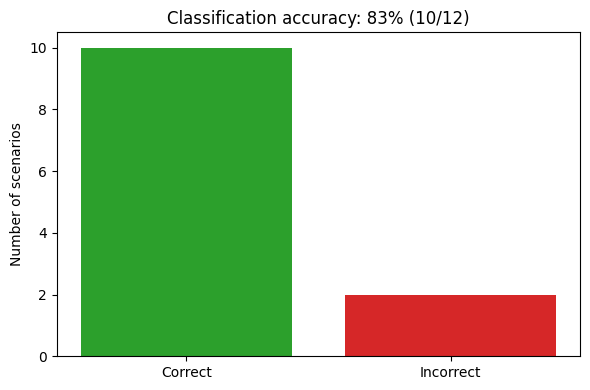

In [9]:
import matplotlib.pyplot as plt

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# 1. Classification accuracy
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Correct", "Incorrect"], [n_correct, n_incorrect], color=["tab:green", "tab:red"])
ax.set_title(f"Classification accuracy: {classification_accuracy:.0%} ({n_correct}/{len(results)})")
ax.set_ylabel("Number of scenarios")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_eval_classification.png", dpi=150)
plt.show()

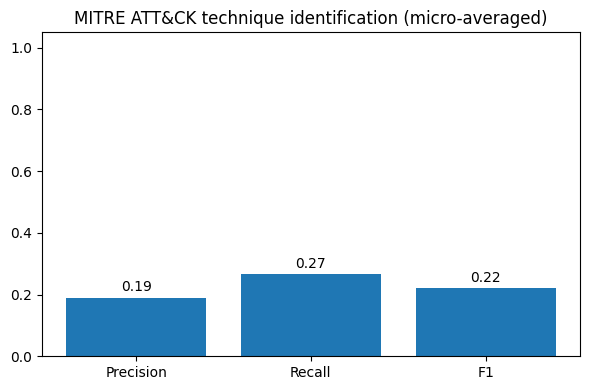

In [10]:
# 2. MITRE precision / recall / F1
fig, ax = plt.subplots(figsize=(6, 4))
metrics_names = ["Precision", "Recall", "F1"]
metrics_values = [micro_precision, micro_recall, micro_f1]
ax.bar(metrics_names, metrics_values, color="tab:blue")
ax.set_ylim(0, 1.05)
for i, v in enumerate(metrics_values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.set_title("MITRE ATT&CK technique identification (micro-averaged)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_eval_mitre.png", dpi=150)
plt.show()

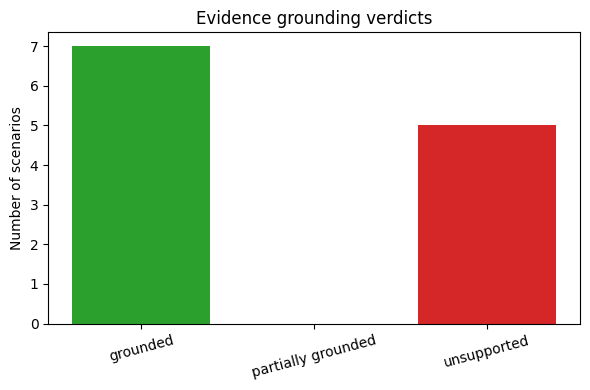

In [11]:
# 3. Grounding results
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["grounded", "partially grounded", "unsupported"]
counts = [grounding_counts.get(label, 0) for label in labels]
ax.bar(labels, counts, color=["tab:green", "tab:orange", "tab:red"])
ax.set_ylabel("Number of scenarios")
ax.set_title("Evidence grounding verdicts")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_eval_grounding.png", dpi=150)
plt.show()

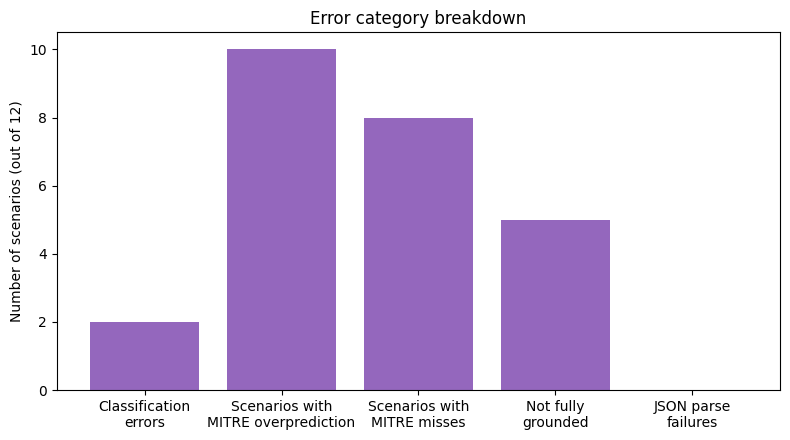

Saved: security_eval_classification.png, security_eval_mitre.png, security_eval_grounding.png, security_eval_errors.png


In [12]:
# 4. Error category breakdown
n_classification_errors = n_incorrect
n_mitre_fp_scenarios = sum(1 for r in results if r["mitre"]["fp"])
n_mitre_fn_scenarios = sum(1 for r in results if r["mitre"]["fn"])
n_not_grounded = sum(1 for r in results if r["grounding_verdict"] != "grounded")
n_parse_failures = sum(1 for r in results if r["parsed"] is None)

error_categories = {
    "Classification\nerrors": n_classification_errors,
    "Scenarios with\nMITRE overprediction": n_mitre_fp_scenarios,
    "Scenarios with\nMITRE misses": n_mitre_fn_scenarios,
    "Not fully\ngrounded": n_not_grounded,
    "JSON parse\nfailures": n_parse_failures,
}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(error_categories.keys(), error_categories.values(), color="tab:purple")
ax.set_ylabel(f"Number of scenarios (out of {len(results)})")
ax.set_title("Error category breakdown")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_eval_errors.png", dpi=150)
plt.show()

print("Saved: security_eval_classification.png, security_eval_mitre.png, security_eval_grounding.png, security_eval_errors.png")

## Section 15 -- Final learning summary

The key lesson is that model quality is not a single number. A production AI product needs task-specific evaluation, golden datasets, regression tests, human review, and clear failure criteria.

This notebook is a small, self-contained illustration of that idea: the same 12 scenarios produced a classification accuracy, a MITRE precision/recall/F1, a grounding percentage, and a completeness score -- four different numbers that each captured something the others missed entirely. A model could score well on one and poorly on another, and knowing only one of them would have given a false picture of "is this any good." That's the whole argument for building an evaluation harness like this one before trusting a foundation model's output in a SOC workflow, rather than after.

This notebook deliberately does not compare Foundation-Sec against Claude, GPT, or any other general-purpose model -- that comparison, and what it would actually mean for the "domain-specialized vs. general-purpose" question, is a later experiment.